In [17]:
import pandas as pd
# import matplotlib.pyplot as plt
import numpy as np
# import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt


In [18]:
df=pd.read_table('Fig1c.txt')
df.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
0,8241,Liarum,Sweden,55.9473,13.8210,CS77038,leaf,Sweden_leaf,6425.217028,6.800000,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6203,TDr-18,Sweden,55.7714,14.1208,CS77350,leaf,Sweden_leaf,6106.090545,7.400000,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5984,DraIV 6-13,Czech Republic,49.4112,16.2815,CS76822,leaf,Czech Republic_leaf,5937.667641,7.395833,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,9399,Hamm-1,Sweden,55.4234,13.9905,CS76910,leaf,Sweden_leaf,5936.194976,7.937500,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,8420,Kelsterbach-4,GER,50.0667,8.5333,CS76525,leaf,GER_leaf,5842.619693,10.337500,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [19]:
df=df.rename(columns={'coarse_frag':'coarse frag',
                   'bulk_density':'bulk density',
                   'CaCO3':'CaCO$_3$',
                     'ph':'pH',
                     'ai':'AI',
                     'awc':'AWC'})

In [20]:
df=df[df.duplicated(subset=['Country'],keep=False)]

In [21]:
X=df.drop(columns=['Mg25'])
y=df['Mg25']

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = X['Country'])

In [108]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
287,10.170834,7.791667,38.008129,472.076935,22.000000,1.5,20.500000,7.750000,6.483333,16.266666,...,5.772104,13.715875,13.949490,0.000000,2.615070,26.493233,188.694763,31,-0.018588,0.031255
56,11.250000,9.366667,31.537598,767.673584,27.000000,-2.7,29.700001,16.600000,1.733333,20.616667,...,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.019555,-0.014141
663,16.216667,7.050000,31.756756,558.245361,28.600000,6.4,22.200001,14.266666,23.100000,23.350000,...,6.880644,10.763082,15.530464,83.813835,1.907678,20.237658,351.257385,24,-0.022566,0.022191
45,11.250000,9.366667,31.537598,767.673584,27.000000,-2.7,29.700001,16.600000,1.733333,20.616667,...,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.020433,-0.013291
47,9.162500,9.158334,32.708332,712.489624,24.200001,-3.8,28.000000,18.016666,0.583333,18.016666,...,6.397152,13.569145,20.028221,61.336304,1.893738,16.866127,198.365829,52,-0.022620,-0.004213


In [109]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
665,9.137500,8.541667,32.354797,653.845703,24.5,-1.9,26.400000,5.616667,17.733334,17.733334,...,6.508832,11.860096,14.233815,55.321808,1.747500,25.260445,107.610245,61,0.118787,0.045686
228,9.162500,10.725000,38.579136,609.873779,25.1,-2.7,27.800001,6.233333,2.966667,17.200001,...,6.392577,14.800039,20.528246,49.911823,3.750896,11.483948,216.613678,48,0.082162,0.031614
49,8.941667,6.766666,31.039755,577.182922,21.1,-0.7,21.800001,16.100000,4.600000,16.100000,...,6.241703,10.743577,19.869848,0.692850,3.875818,64.735283,137.428818,48,0.007429,-0.017109
375,11.250000,9.366667,31.537598,767.673584,27.0,-2.7,29.700001,16.600000,1.733333,20.616667,...,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.013151,-0.009219
319,8.470834,8.708333,33.493591,656.614807,22.9,-3.1,26.000000,15.033333,1.650000,16.666666,...,6.613173,11.282214,27.255800,84.860046,2.696891,24.213699,206.133362,47,-0.035502,0.004888


In [114]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 42)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=5)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 6, 'max_leaf_nodes': 8, 'n_estimators': 200}
0.15064500978464146


In [115]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 310.35
Mean Squared Error: 158711.7
R-squared scores: 0.26


In [116]:
from sklearn.inspection import permutation_importance

result = permutation_importance(forest_model_cv, X_test, y_test, n_repeats=100, n_jobs=4)
model_importances = pd.Series(result.importances_mean, index=X_train.columns)

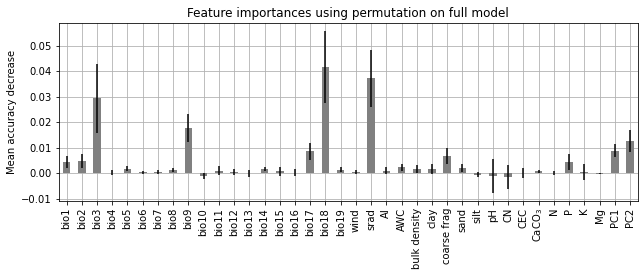

In [117]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c_20240912.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [62]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
488,10.391666,5.750000,36.858974,371.188721,19.000000,3.4,15.600000,7.233333,13.500000,15.166666,...,5.519815,14.143741,14.984841,7.479748,2.761479,45.450233,193.933990,36,-0.005946,0.016586
610,9.462500,7.658333,31.005398,649.090698,23.299999,-1.4,24.699999,16.049999,5.283333,17.633333,...,6.342852,13.401412,10.437699,27.449533,2.232157,43.846073,301.996765,46,-0.022019,0.003444
647,13.729167,8.091666,32.627686,615.801269,27.700001,2.9,24.800001,11.083333,21.666666,21.666666,...,6.842742,12.490710,21.039680,102.480187,2.467388,12.372148,840.274902,41,-0.017383,0.017000
62,11.287500,9.175000,33.731617,653.769226,27.000000,-0.2,27.200001,7.550000,19.766666,19.850000,...,6.292581,14.308894,7.585775,50.518814,1.273731,21.246906,218.963242,57,0.003521,0.031870
212,11.250000,9.366667,31.537598,767.673584,27.000000,-2.7,29.700001,16.600000,1.733333,20.616667,...,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.024136,-0.013067


In [63]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
215,11.345834,10.891666,40.339504,585.093079,27.000000,0.0,27.000000,12.933333,18.816666,18.816666,...,8.016591,11.245294,17.563269,332.303925,1.514916,17.759943,252.585419,30,0.021888,0.028309
314,7.016667,9.833334,32.777779,764.327820,23.200001,-6.8,30.000000,14.883333,-1.116667,16.299999,...,5.480967,10.898319,14.342714,24.778873,2.714808,20.880541,152.505692,56,-0.036828,-0.012471
307,8.837500,9.625000,34.010601,708.423767,24.100000,-4.2,28.299999,12.216666,14.216667,17.483334,...,6.727628,12.976003,28.928238,121.268051,1.639980,9.403410,198.062851,33,-0.022517,0.013944
302,14.925000,8.950000,36.382114,564.444641,29.799999,5.2,24.599998,9.666667,22.200001,22.516666,...,5.995533,12.332913,10.039244,31.118629,2.581114,25.464487,367.282715,31,0.023853,0.050645
635,9.350000,10.533334,38.583637,602.034424,25.200001,-2.1,27.300001,10.816667,17.150000,17.150000,...,6.366279,13.337726,11.052263,2.226088,1.953779,12.625140,146.855743,17,0.034276,0.030819


In [64]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 42)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 4, 'max_leaf_nodes': 6, 'n_estimators': 200}
0.1877959145835403


In [65]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 308.06
Mean Squared Error: 151280.93
R-squared scores: 0.16


In [66]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=1, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

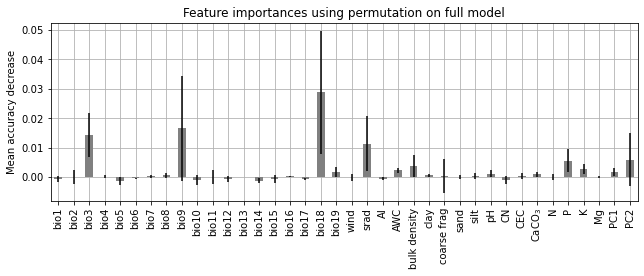

In [67]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c_20240912.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [186]:
from sklearn.ensemble import RandomForestRegressor
forest_model= RandomForestRegressor(max_depth=5, random_state=0,n_estimators=100)
forest_model.fit(X_train, y_train)
Y_pred=forest_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 308.38
Mean Squared Error: 163897.12
R-squared scores: 0.23


In [187]:
forest_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'mse',
 'max_depth': 5,
 'max_features': 'auto',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_impurity_split': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}

In [130]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=10, random_state=0, n_jobs=4,scoring = 'explained_variance'
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

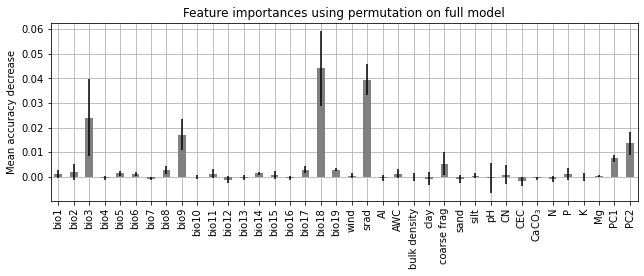

In [131]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# With the most important variables

In [13]:
X_train=X_train[['bio3','bio9','bio18','srad','PC1','PC2']]
X_test=X_test[['bio3','bio9','bio18','srad','PC1','PC2']]

In [14]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 4, 'max_leaf_nodes': 8, 'n_estimators': 200}
0.1615719597458421


In [15]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 302.75
Mean Squared Error: 152078.94
R-squared scores: 0.29


In [16]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

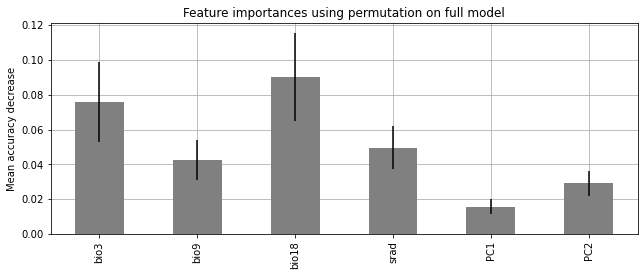

In [17]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0,stratify=X['Country'])

In [39]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
338,11.833333,12.200000,40.666668,641.373962,29.4,-0.6,30.0,8.016666,19.916666,20.083332,...,6.899363,13.557681,6.669714,40.862068,1.037124,12.179875,182.163422,57,0.036116,0.043223
445,3.629167,7.491666,25.922722,762.541992,19.4,-9.5,28.9,4.016666,1.950000,13.650000,...,4.512662,23.880318,10.086387,4.951549,2.901053,30.837130,168.004746,37,0.086412,-0.127331
205,8.316667,6.400000,27.234041,650.598816,21.6,-1.9,23.5,8.933333,3.133333,16.600000,...,5.973516,15.454953,9.803944,6.839525,2.147695,33.340641,156.426300,34,0.012252,-0.076562
567,8.216666,9.133333,34.595959,657.181763,23.0,-3.4,26.4,14.766666,1.350000,16.433332,...,6.927029,9.657534,18.917164,46.665848,2.671047,39.574181,211.958344,47,-0.035339,0.013327
369,6.375000,9.516666,33.275059,700.426819,22.6,-6.0,28.6,14.266667,1.083333,15.416667,...,5.061326,21.420122,12.911974,0.000000,2.227679,19.856781,101.202622,34,-0.008671,-0.043659


In [40]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
458,11.933333,10.366667,33.440861,770.912476,28.700001,-2.3,31.000000,7.433333,20.766666,21.450001,...,6.440167,12.452619,21.869532,100.943146,1.297026,17.429489,216.298584,36,-0.025715,0.010085
366,10.404167,9.091667,35.653595,588.659729,24.700001,-0.8,25.500000,11.350000,4.433333,18.083334,...,6.456506,14.365889,21.624945,35.337105,1.417475,21.751728,280.285187,43,0.031265,0.033499
454,14.375000,11.266666,36.699242,695.999939,32.099998,1.4,30.699999,10.216667,23.316666,23.516666,...,7.039402,9.917389,11.263844,143.233261,1.404741,23.023563,410.993897,63,0.030154,0.048431
342,5.337500,7.625000,28.773584,695.286499,20.400000,-6.1,26.500000,13.116667,-0.033333,14.266666,...,4.324504,22.881643,13.129420,0.000000,3.240004,16.466581,118.408272,26,-0.004129,-0.036453
375,11.250000,9.366667,31.537598,767.673584,27.000000,-2.7,29.700001,16.600000,1.733333,20.616667,...,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.013151,-0.009219


In [46]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=3)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 5, 'max_leaf_nodes': 7, 'n_estimators': 100}
0.18700537639750545


In [47]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 297.1
Mean Squared Error: 138041.73
R-squared scores: 0.23


In [48]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

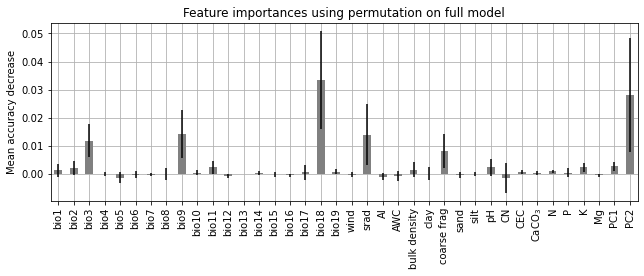

In [49]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

# With the most important variables

In [50]:
X_train=X_train[['bio3','bio9','bio18','srad','coarse frag','PC1','PC2']]
X_test=X_test[['bio3','bio9','bio18','srad','coarse frag','PC1','PC2']]

In [51]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=3)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 6, 'max_leaf_nodes': 9, 'n_estimators': 100}
0.20375205538428087


In [52]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 297.37
Mean Squared Error: 136237.71
R-squared scores: 0.24


In [53]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

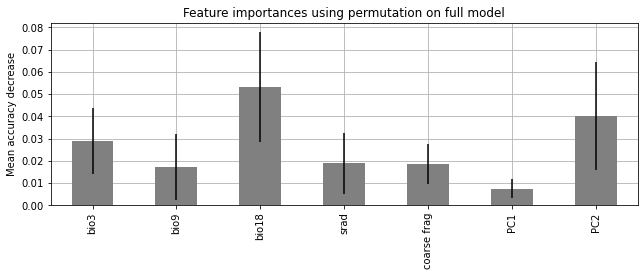

In [54]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [55]:
df=pd.read_table('Fig1c.txt')
df.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
0,8241,Liarum,Sweden,55.9473,13.8210,CS77038,leaf,Sweden_leaf,6425.217028,6.800000,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6203,TDr-18,Sweden,55.7714,14.1208,CS77350,leaf,Sweden_leaf,6106.090545,7.400000,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5984,DraIV 6-13,Czech Republic,49.4112,16.2815,CS76822,leaf,Czech Republic_leaf,5937.667641,7.395833,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,9399,Hamm-1,Sweden,55.4234,13.9905,CS76910,leaf,Sweden_leaf,5936.194976,7.937500,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,8420,Kelsterbach-4,GER,50.0667,8.5333,CS76525,leaf,GER_leaf,5842.619693,10.337500,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [56]:
df=df.rename(columns={'coarse_frag':'coarse frag',
                   'bulk_density':'bulk density',
                   'CaCO3':'CaCO$_3$',
                     'ph':'pH',
                     'ai':'AI',
                     'awc':'AWC'})

In [57]:
df=df[df.duplicated(subset=['Country'],keep=False)]

In [58]:
X=df.drop(columns=['Mg25'])
y=df['Mg25']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42,stratify=X['Country'])

In [62]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train[['AWC','bulk density','clay','coarse frag','sand','silt','pH','CN','CEC','CaCO$_3$','N','P','K','Mg','PC1','PC2']]
X_train.head()

,AWC,bulk density,clay,coarse frag,sand,silt,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
287,0.080917,1.046375,11.811131,13.713201,62.608646,25.580223,5.772104,13.715875,13.949490,0.000000,2.615070,26.493233,188.694763,31,-0.018588,0.031255
56,0.099277,1.121258,17.424967,31.138071,42.329781,40.245255,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.019555,-0.014141
663,0.104049,1.319919,33.951282,20.107779,31.318375,34.730347,6.880644,10.763082,15.530464,83.813835,1.907678,20.237658,351.257385,24,-0.022566,0.022191
45,0.099277,1.121258,17.424967,31.138071,42.329781,40.245255,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.020433,-0.013291
47,0.113647,0.996389,21.592152,28.466803,44.409637,33.998215,6.397152,13.569145,20.028221,61.336304,1.893738,16.866127,198.365829,52,-0.022620,-0.004213


In [63]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test[['AWC','bulk density','clay','coarse frag','sand','silt','pH','CN','CEC','CaCO$_3$','N','P','K','Mg','PC1','PC2']]
X_test.head()

,AWC,bulk density,clay,coarse frag,sand,silt,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
665,0.105172,1.073648,17.520901,32.694847,50.451889,32.027206,6.508832,11.860096,14.233815,55.321808,1.747500,25.260445,107.610245,61,0.118787,0.045686
228,0.121553,1.028331,22.302279,14.895372,44.570267,33.127457,6.392577,14.800039,20.528246,49.911823,3.750896,11.483948,216.613678,48,0.082162,0.031614
49,0.094790,1.040279,21.136608,6.350376,53.893608,24.969788,6.241703,10.743577,19.869848,0.692850,3.875818,64.735283,137.428818,48,0.007429,-0.017109
375,0.099277,1.121258,17.424967,31.138071,42.329781,40.245255,6.699357,12.379600,18.192663,105.279900,1.976948,30.124363,168.221390,52,-0.013151,-0.009219
319,0.096514,1.142878,22.724215,13.408038,30.156143,47.119644,6.613173,11.282214,27.255800,84.860046,2.696891,24.213699,206.133362,47,-0.035502,0.004888


In [64]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 4, 'max_leaf_nodes': 9, 'n_estimators': 100}
0.16399732210145238


In [65]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 313.06
Mean Squared Error: 162971.05
R-squared scores: 0.24


In [66]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

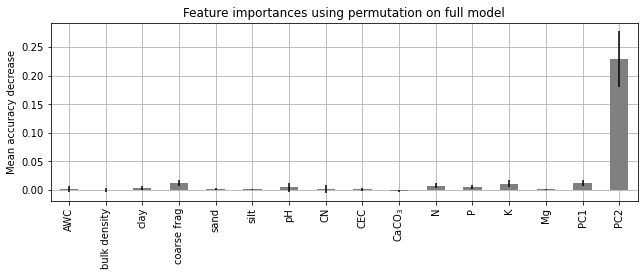

In [67]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [69]:
s = StandardScaler()
X_train_s = s.fit_transform(X_train)
X_test_s = s.transform(X_test)

In [70]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train_s,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 4, 'max_leaf_nodes': 9, 'n_estimators': 100}
0.16417649247695257


In [71]:
y_pred=forest_model_cv.predict(X_test_s)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 313.06
Mean Squared Error: 162971.05
R-squared scores: 0.24


In [72]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test_s, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

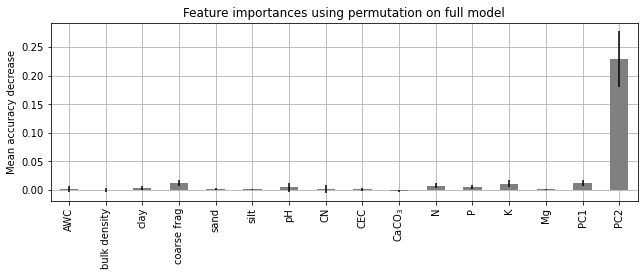

In [73]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")

In [74]:
lr_model= LinearRegression()
lr_model.fit(X_train_s,y_train)
y_pred=lr_model.predict(X_test_s)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('R-squared scores:', round(r2, 3))

R-squared scores: 0.19


In [75]:

print(r2_score(y_train.values.ravel(), lr_model.predict(X_train_s)))

0.16355375781626535


In [112]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    lr_model, X_test_s, y_test, n_repeats=10, random_state=1, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

In [240]:
df=pd.read_table('Fig1c.txt')
df.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
0,8241,Liarum,Sweden,55.9473,13.8210,CS77038,leaf,Sweden_leaf,6425.217028,6.800000,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6203,TDr-18,Sweden,55.7714,14.1208,CS77350,leaf,Sweden_leaf,6106.090545,7.400000,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5984,DraIV 6-13,Czech Republic,49.4112,16.2815,CS76822,leaf,Czech Republic_leaf,5937.667641,7.395833,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,9399,Hamm-1,Sweden,55.4234,13.9905,CS76910,leaf,Sweden_leaf,5936.194976,7.937500,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,8420,Kelsterbach-4,GER,50.0667,8.5333,CS76525,leaf,GER_leaf,5842.619693,10.337500,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [241]:
df=df.rename(columns={'coarse_frag':'coarse frag',
                   'bulk_density':'bulk density',
                   'CaCO3':'CaCO$_3$',
                     'ph':'pH',
                     'ai':'AI',
                     'awc':'AWC'})

In [242]:
df=df[df.duplicated(subset=['Country'],keep=False)]

In [243]:
X=df.drop(columns=['Mg25'])
y=df['Mg25']

In [256]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1, stratify=X['Country'])

In [257]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train[['bio1', 'bio12', 'wind', 'srad', 'AI', 'AWC', 'bulk density', 'clay', 'coarse frag', 'sand', 'silt', 'pH', 'CN', 'CEC', 'CaCO$_3$', 'N', 'P', 'K', 'Mg', 'PC1', 'PC2']]
X_train.head()

,bio1,bio12,wind,srad,AI,AWC,bulk density,clay,coarse frag,sand,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
291,5.237500,2324,8.950000,8753.833008,4.5936,0.084703,1.173659,8.574111,16.972645,76.223343,...,5.896673,16.676334,22.603813,33.574959,5.221364,17.010656,151.997192,41,-0.023946,0.029012
258,3.366667,721,3.950000,8997.500000,1.1566,0.073481,1.180028,5.527149,9.050817,80.686974,...,4.373578,29.304379,9.972311,0.000000,1.570728,29.569914,169.067368,37,0.082719,-0.129257
541,3.491667,737,4.091667,9029.750000,1.1923,0.076293,1.171590,7.871578,21.284988,71.909088,...,4.477750,24.041798,11.098902,4.859886,3.579735,28.267197,165.351166,37,0.082439,-0.117928
82,10.016666,655,2.783333,10449.416990,0.7322,0.074518,1.300466,23.152197,12.965901,31.102806,...,6.856537,13.830351,13.954475,33.492100,2.453425,26.683350,229.511368,43,-0.031453,0.004519
462,7.808333,1011,2.866667,11379.083010,1.1839,0.102342,1.348538,22.505827,14.259891,37.060196,...,6.798384,9.342006,24.751244,29.261488,3.283556,40.150414,106.628159,50,-0.022256,-0.036172


In [258]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test[['bio1', 'bio12', 'wind', 'srad', 'AI', 'AWC', 'bulk density', 'clay', 'coarse frag', 'sand', 'silt', 'pH', 'CN', 'CEC', 'CaCO$_3$', 'N', 'P', 'K', 'Mg', 'PC1', 'PC2']]
X_test.head()

,bio1,bio12,wind,srad,AI,AWC,bulk density,clay,coarse frag,sand,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
281,7.841667,728,3.283333,9796.666992,0.9476,0.068908,1.175611,9.930075,7.869449,68.739670,...,5.734431,15.949379,10.526954,12.689724,2.057792,33.323174,126.452728,37,-0.021625,-0.039374
253,7.470833,853,5.925000,8731.000000,1.2676,0.112081,1.011537,18.853790,12.585914,52.453041,...,5.146155,16.163998,17.589560,17.683481,2.965231,22.964167,208.571930,39,-0.010270,0.020176
621,6.758333,637,3.233333,9930.250000,0.8778,0.072721,1.140362,7.422073,17.387733,71.867203,...,5.481523,15.905890,10.472198,0.631824,2.619578,25.933889,51.603909,38,-0.011531,-0.023032
554,9.595833,648,2.791667,10150.083010,0.7501,0.081129,1.438898,18.073748,10.265512,46.660049,...,6.336513,13.518221,11.611878,6.802540,1.456952,40.914745,158.122803,41,-0.045964,-0.005282
566,7.100000,767,2.800000,9784.416992,1.0688,0.075361,1.109085,11.749794,14.684708,52.872604,...,5.626196,13.635001,12.867762,21.047009,1.974118,32.950397,93.532547,33,-0.008947,-0.025711


In [259]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train_s,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 2, 'max_leaf_nodes': 2, 'n_estimators': 200}
-0.026082029572619847


In [260]:
y_pred=forest_model_cv.predict(X_test_s)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 304.17
Mean Squared Error: 150192.73
R-squared scores: 0.01


In [261]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test_s, y_test, n_repeats=100, random_state=1, n_jobs=4,
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

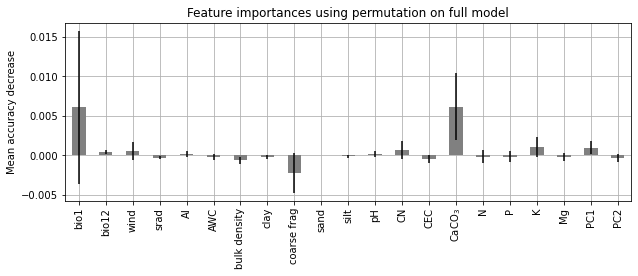

In [262]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")